<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/ml/12-unsupervised-learning/PCA/Project_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Create a dataset

In [2]:
X, y = make_blobs(n_samples = 2000, n_features = 5)
X.shape

(2000, 5)

# Standardized the data

In [3]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# Applying PCA

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-1.69482524, -1.29921175],
       [-0.28049121,  1.92590485],
       [ 2.23805443, -0.45433881],
       ...,
       [-1.67580627, -1.44420314],
       [ 2.19794336, -0.78379653],
       [ 2.11643149, -0.16696631]])

# Finding Variance Ratio

In [5]:
print(pca.explained_variance_ratio_)

[0.51949476 0.45715792]


In [6]:
print(np.sum(pca.explained_variance_ratio_))

0.9766526860663493


# Elbow Method for Optimal Clusters

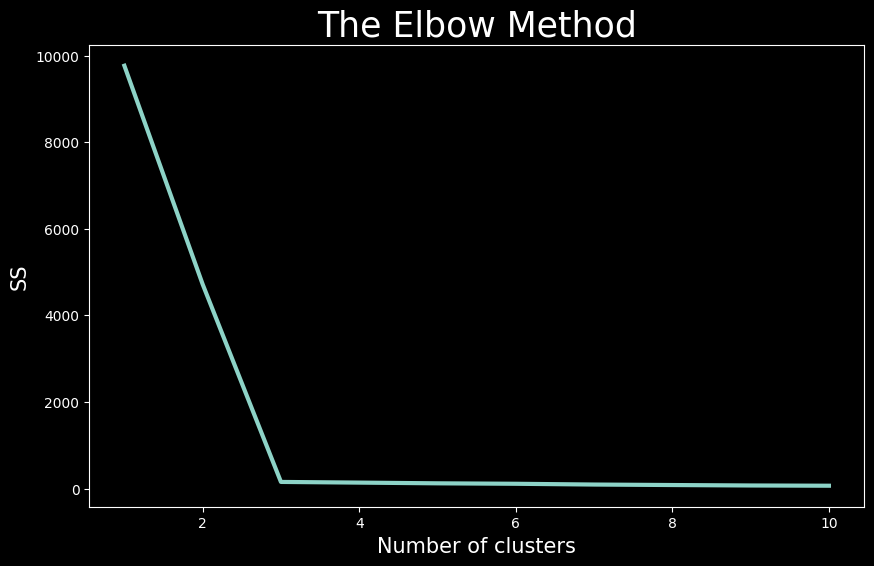

In [7]:
from sklearn.cluster import KMeans
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_pca)
    ss.append(kmeans.inertia_) # kmeans.inertia_ will give us wcss value
plt.figure(figsize = (10,6))
plt.plot(range(1, 11), ss, lw = 3)
plt.title('The Elbow Method', fontsize = 25)
plt.xlabel('Number of clusters', fontsize = 15)
plt.ylabel('SS', fontsize =15 )
plt.show()

# Applying KMeans Clustering

In [8]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_pred = kmeans.fit_predict(X_pca)

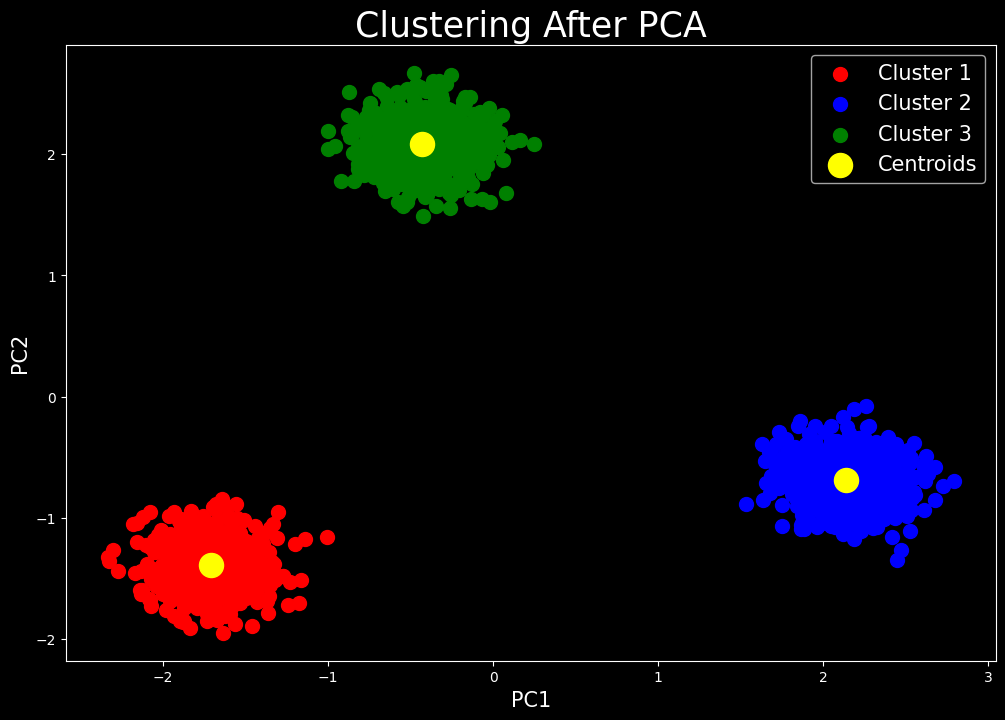

In [9]:
plt.figure(figsize = (12,8))
plt.scatter(X_pca[y_pred == 0, 0], X_pca[y_pred == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X_pca[y_pred == 1, 0], X_pca[y_pred == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X_pca[y_pred == 2, 0], X_pca[y_pred == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clustering After PCA', fontsize = 25)
plt.xlabel('PC1', fontsize = 15)
plt.ylabel('PC2', fontsize = 15)
plt.legend(fontsize = 15)
plt.show()